# December 2025 Status

(Most of these code chunks are me redoing some of the slides that I currently have in my slidedeck)

(see message thread with Evey on Jan 8 2026 for reference)

## Slide 3 - Time Summation

=== FILE COVERAGE (pre-run) ===
Total JSON files found: 809
Session_outcomes files excluded: 8
Candidate session files scanned: 801

=== FILE COVERAGE (post-run) ===
Skip summary: {'load_fail': 0, 'no_utterances': 636, 'too_few_timestamps': 1, 'no_rows_after_filters': 8}
Sessions contributing at least 1 coded utterance: 156
Rows in df: 44370


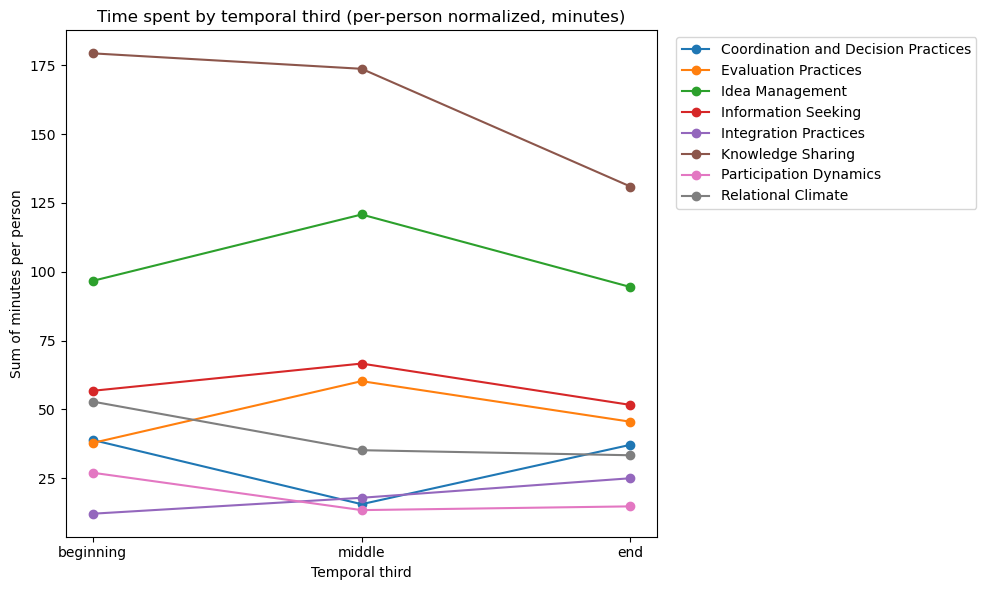

code,when,Coordination and Decision Practices,Evaluation Practices,Idea Management,Information Seeking,Integration Practices,Knowledge Sharing,Participation Dynamics,Relational Climate
0,beginning,38.892210,37.828009,96.710728,56.766349,12.109595,179.369813,26.991075,52.840434
1,middle,15.568522,60.268856,120.820733,66.658447,17.896984,173.755457,13.413868,35.182812
2,end,37.142128,45.529101,94.473047,51.638279,24.993976,130.974741,14.773891,33.347467


In [1]:
import os, json, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = '/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data'  # <-- change this
# For quick testing with your uploaded sample in this environment, uncomment:
# BASE_DIR = "/mnt/data"

TEMPORAL_ORDER = ["beginning", "middle", "end"]

# Multi-label handling:
# False = full duration credited to every code present (allows overlaps)
# True  = split duration evenly across all codes in that utterance (no within-utterance double count)
SPLIT_MULTI_LABEL_TIME = False

IGNORE_CODES = {"None", "Other", ""}

# If timestamps wrap (e.g., 09:39 -> 00:29), we "unwrap" them by adding an offset.
# This threshold (seconds) decides what counts as a wrap. 30s is conservative.
WRAP_THRESHOLD_SEC = 30


# =========================
# HELPERS
# =========================
def safe_load_json(path: str):
    with open(path, "r") as f:
        return json.load(f)

def extract_utterances(obj):
    """
    Tries common structures for your utterance-level session JSONs.
    Your example uses 'all_data'.
    """
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for k in ["all_data", "utterances", "utterance_list", "data", "items"]:
            if k in obj and isinstance(obj[k], list):
                return obj[k]
    return None

def to_seconds(val):
    if val is None:
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    try:
        return float(str(val).strip())
    except:
        return np.nan

def parse_timestamp_to_sec(ts):
    """
    Accepts:
      - "MM:SS"
      - "HH:MM:SS"
    Returns seconds or NaN.
    """
    if ts is None:
        return np.nan
    s = str(ts).strip()
    if not s:
        return np.nan
    parts = s.split(":")
    try:
        parts = [int(p) for p in parts]
    except:
        return np.nan
    if len(parts) == 2:
        mm, ss = parts
        return mm * 60 + ss
    if len(parts) == 3:
        hh, mm, ss = parts
        return hh * 3600 + mm * 60 + ss
    return np.nan

def unwrap_time(seconds_list, wrap_threshold=WRAP_THRESHOLD_SEC):
    """
    Make a sequence monotonic by adding offsets when it appears to reset.
    If time goes backwards by more than threshold, treat as wrap/reset and add 3600s
    until monotonic.
    """
    out = []
    offset = 0.0
    prev = None
    for x in seconds_list:
        if not np.isfinite(x):
            out.append(np.nan)
            continue
        if prev is not None and np.isfinite(prev):
            if x < prev - wrap_threshold:
                while x + offset < prev:
                    offset += 3600.0
        gx = x + offset
        out.append(gx)
        prev = gx
    return out

def is_session_outcomes_file(path: str):
    return os.path.basename(path).endswith("_session_outcomes.json")


# =========================
# SCAN FILES + COVERAGE REPORTING
# =========================
json_paths = glob.glob(os.path.join(BASE_DIR, "**", "*.json"), recursive=True)
outcomes_paths = [p for p in json_paths if is_session_outcomes_file(p)]
session_paths = [p for p in json_paths if not is_session_outcomes_file(p)]

print("=== FILE COVERAGE (pre-run) ===")
print("Total JSON files found:", len(json_paths))
print("Session_outcomes files excluded:", len(outcomes_paths))
print("Candidate session files scanned:", len(session_paths))

skip = {
    "load_fail": 0,
    "no_utterances": 0,
    "too_few_timestamps": 0,
    "no_rows_after_filters": 0,
}

rows = []
processed_sessions = set()


for path in session_paths:
    try:
        obj = safe_load_json(path)
    except Exception:
        skip["load_fail"] += 1
        continue

    utterances = extract_utterances(obj)
    if not utterances:
        skip["no_utterances"] += 1
        continue

    # Use a unique-ish session id (path-relative) to avoid filename collisions across conferences
    session_id = os.path.relpath(path, BASE_DIR).replace(os.sep, "__").replace(".json", "")

    rows_before = len(rows)

    # Speakers for per-person normalization
    speakers = {(u.get("speaker") or "").strip() for u in utterances}
    speakers = {s for s in speakers if s}
    n_speakers = max(len(speakers), 1)

    # Build a per-utterance time axis (prefer start_time; else timestamp)
    t_raw = []
    for u in utterances:
        st = u.get("start_time", None)
        ts = u.get("timestamp", None)
        sec = parse_timestamp_to_sec(st) if st is not None else parse_timestamp_to_sec(ts)
        t_raw.append(sec)

    # Unwrap to global monotonic time within the session
    global_sec = unwrap_time(t_raw)

    # If all NaN, fall back to utterance index
    if np.all(~np.isfinite(global_sec)):
        global_sec = list(range(len(utterances)))

    # Assign temporal thirds from global_sec percentiles
    g = np.array(global_sec, dtype=float)
    if np.isfinite(g).sum() < 3:
        skip["too_few_timestamps"] += 1
        continue

    g_min, g_max = np.nanmin(g), np.nanmax(g)
    if g_max == g_min:
        g_norm = np.zeros_like(g)
    else:
        g_norm = (g - g_min) / (g_max - g_min)

    third_label = np.full(len(g_norm), None, dtype=object)
    third_label[(g_norm >= 0.0) & (g_norm < 1/3)] = "beginning"
    third_label[(g_norm >= 1/3) & (g_norm < 2/3)] = "middle"
    third_label[(g_norm >= 2/3) & (g_norm <= 1.0)] = "end"

    for u, when in zip(utterances, third_label):
        if when not in TEMPORAL_ORDER:
            continue

        dur_sec = to_seconds(u.get("speaking_duration"))
        if not np.isfinite(dur_sec) or dur_sec <= 0:
            continue

        ann = u.get("annotations", {})
        if not isinstance(ann, dict) or len(ann) == 0:
            continue

        codes = [c.strip() for c in ann.keys() if isinstance(c, str)]
        codes = [c for c in codes if c not in IGNORE_CODES]
        if not codes:
            continue

        if SPLIT_MULTI_LABEL_TIME:
            per_code_sec = dur_sec / len(codes)
        else:
            per_code_sec = dur_sec

        # Convert to minutes *after* multi-label logic
        per_code_min = per_code_sec / 60.0
        per_code_min_per_person = per_code_min / n_speakers

        for code in codes:
            rows.append({
                "session_id": session_id,
                "when": when,
                "code": code,
                "time_min_per_person": per_code_min_per_person,
            })

    if len(rows) == rows_before:
        skip["no_rows_after_filters"] += 1
    else:
        processed_sessions.add(session_id)


df = pd.DataFrame(rows)

print("\n=== FILE COVERAGE (post-run) ===")
print("Skip summary:", skip)
print("Sessions contributing at least 1 coded utterance:", len(processed_sessions))
print("Rows in df:", len(df))

if df.empty:
    raise ValueError(
        "No utterance annotations found. Likely BASE_DIR is pointing at the wrong folder, "
        "or your individual session files store utterances under a different key than expected."
    )

# =========================
# AGGREGATE + PLOT (MINUTES)
# =========================
agg = df.groupby(["code", "when"], as_index=False)["time_min_per_person"].sum()
agg["when"] = pd.Categorical(agg["when"], categories=TEMPORAL_ORDER, ordered=True)
agg = agg.sort_values(["code", "when"])

wide = agg.pivot(index="when", columns="code", values="time_min_per_person").fillna(0.0)
wide = wide.loc[TEMPORAL_ORDER]

plt.figure(figsize=(10, 6))
for code in wide.columns:
    plt.plot(wide.index.astype(str), wide[code].values, marker="o", label=code)

plt.title("Time spent by temporal third (per-person normalized, minutes)")
plt.xlabel("Temporal third")
plt.ylabel("Sum of minutes per person")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(wide.reset_index())

## Slide 3 - Code Annotation Summation

=== FILE COVERAGE (pre-run) ===
Total JSON files found: 809
Session_outcomes files excluded: 8
Candidate session files scanned: 801

=== FILE COVERAGE (post-run) ===
Skip summary: {'load_fail': 0, 'no_utterances': 636, 'too_few_timestamps': 1, 'no_rows_after_filters': 8}
Sessions contributing at least 1 coded utterance: 156
Rows in df: 46910


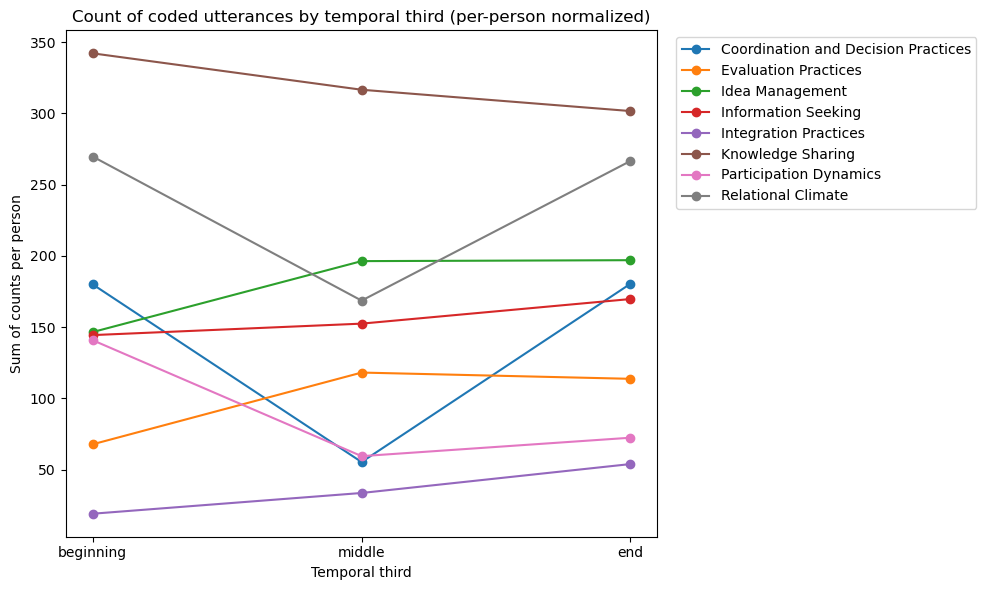

code,when,Coordination and Decision Practices,Evaluation Practices,Idea Management,Information Seeking,Integration Practices,Knowledge Sharing,Participation Dynamics,Relational Climate
0,beginning,179.954750,67.778589,146.544388,144.395960,19.038241,342.143563,140.778523,269.675466
1,middle,55.297938,118.097746,196.314909,152.440817,33.583884,316.602484,59.437393,168.600632
2,end,180.409728,113.713725,196.970621,169.698563,53.876424,301.645214,72.368582,266.586175


In [2]:
import os, json, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = '/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data'
# BASE_DIR = "/mnt/data"  # quick test in this environment

TEMPORAL_ORDER = ["beginning", "middle", "end"]

# Multi-label handling for COUNT:
# False = each utterance contributes +1 to every code present (allows overlaps)
# True  = split 1.0 evenly across all codes in that utterance (no within-utterance double count)
SPLIT_MULTI_LABEL_COUNTS = False

IGNORE_CODES = {"None", "Other", ""}

WRAP_THRESHOLD_SEC = 30


# =========================
# HELPERS
# =========================
def safe_load_json(path: str):
    with open(path, "r") as f:
        return json.load(f)

def extract_utterances(obj):
    """
    Tries common structures for your utterance-level session JSONs.
    Your example uses 'all_data'.
    """
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for k in ["all_data", "utterances", "utterance_list", "data", "items"]:
            if k in obj and isinstance(obj[k], list):
                return obj[k]
    return None

def parse_timestamp_to_sec(ts):
    """
    Accepts:
      - "MM:SS"
      - "HH:MM:SS"
    Returns seconds or NaN.
    """
    if ts is None:
        return np.nan
    s = str(ts).strip()
    if not s:
        return np.nan
    parts = s.split(":")
    try:
        parts = [int(p) for p in parts]
    except:
        return np.nan
    if len(parts) == 2:
        mm, ss = parts
        return mm * 60 + ss
    if len(parts) == 3:
        hh, mm, ss = parts
        return hh * 3600 + mm * 60 + ss
    return np.nan

def unwrap_time(seconds_list, wrap_threshold=WRAP_THRESHOLD_SEC):
    """
    Make a sequence monotonic by adding offsets when it appears to reset.
    If time goes backwards by more than threshold, treat as wrap/reset and add 3600s
    until monotonic.
    """
    out = []
    offset = 0.0
    prev = None
    for x in seconds_list:
        if not np.isfinite(x):
            out.append(np.nan)
            continue
        if prev is not None and np.isfinite(prev):
            if x < prev - wrap_threshold:
                while x + offset < prev:
                    offset += 3600.0
        gx = x + offset
        out.append(gx)
        prev = gx
    return out

def is_session_outcomes_file(path: str):
    return os.path.basename(path).endswith("_session_outcomes.json")


# =========================
# SCAN FILES + COVERAGE REPORTING
# =========================
json_paths = glob.glob(os.path.join(BASE_DIR, "**", "*.json"), recursive=True)
outcomes_paths = [p for p in json_paths if is_session_outcomes_file(p)]
session_paths = [p for p in json_paths if not is_session_outcomes_file(p)]

print("=== FILE COVERAGE (pre-run) ===")
print("Total JSON files found:", len(json_paths))
print("Session_outcomes files excluded:", len(outcomes_paths))
print("Candidate session files scanned:", len(session_paths))

skip = {
    "load_fail": 0,
    "no_utterances": 0,
    "too_few_timestamps": 0,
    "no_rows_after_filters": 0,
}

rows = []
processed_sessions = set()

for path in session_paths:
    try:
        obj = safe_load_json(path)
    except Exception:
        skip["load_fail"] += 1
        continue

    utterances = extract_utterances(obj)
    if not utterances:
        skip["no_utterances"] += 1
        continue

    # Use a unique-ish session id (path-relative) to avoid filename collisions across conferences
    session_id = os.path.relpath(path, BASE_DIR).replace(os.sep, "__").replace(".json", "")

    rows_before = len(rows)

    # Speakers for per-person normalization
    speakers = {(u.get("speaker") or "").strip() for u in utterances}
    speakers = {s for s in speakers if s}
    n_speakers = max(len(speakers), 1)

    # Build a per-utterance time axis (prefer start_time; else timestamp)
    t_raw = []
    for u in utterances:
        st = u.get("start_time", None)
        ts = u.get("timestamp", None)
        sec = parse_timestamp_to_sec(st) if st is not None else parse_timestamp_to_sec(ts)
        t_raw.append(sec)

    # Unwrap to global monotonic time within the session
    global_sec = unwrap_time(t_raw)

    # If all NaN, fall back to utterance index
    if np.all(~np.isfinite(global_sec)):
        global_sec = list(range(len(utterances)))

    # Assign temporal thirds from global_sec percentiles
    g = np.array(global_sec, dtype=float)
    if np.isfinite(g).sum() < 3:
        skip["too_few_timestamps"] += 1
        continue

    g_min, g_max = np.nanmin(g), np.nanmax(g)
    if g_max == g_min:
        g_norm = np.zeros_like(g)
    else:
        g_norm = (g - g_min) / (g_max - g_min)

    third_label = np.full(len(g_norm), None, dtype=object)
    third_label[(g_norm >= 0.0) & (g_norm < 1/3)] = "beginning"
    third_label[(g_norm >= 1/3) & (g_norm < 2/3)] = "middle"
    third_label[(g_norm >= 2/3) & (g_norm <= 1.0)] = "end"

    for u, when in zip(utterances, third_label):
        if when not in TEMPORAL_ORDER:
            continue

        ann = u.get("annotations", {})
        if not isinstance(ann, dict) or len(ann) == 0:
            continue

        codes = [c.strip() for c in ann.keys() if isinstance(c, str)]
        codes = [c for c in codes if c not in IGNORE_CODES]
        if not codes:
            continue

        # COUNT contribution per utterance
        if SPLIT_MULTI_LABEL_COUNTS:
            per_code_count = 1.0 / len(codes)
        else:
            per_code_count = 1.0

        per_code_count_per_person = per_code_count / n_speakers

        for code in codes:
            rows.append({
                "session_id": session_id,
                "when": when,
                "code": code,
                "count_per_person": per_code_count_per_person,
            })

    if len(rows) == rows_before:
        skip["no_rows_after_filters"] += 1
    else:
        processed_sessions.add(session_id)


df = pd.DataFrame(rows)

print("\n=== FILE COVERAGE (post-run) ===")
print("Skip summary:", skip)
print("Sessions contributing at least 1 coded utterance:", len(processed_sessions))
print("Rows in df:", len(df))

if df.empty:
    raise ValueError(
        "No utterance annotations found. Likely BASE_DIR is pointing at the wrong folder, "
        "or your individual session files store utterances under a different key than expected."
    )

# =========================
# AGGREGATE + PLOT (COUNTS)
# =========================
agg = df.groupby(["code", "when"], as_index=False)["count_per_person"].sum()
agg["when"] = pd.Categorical(agg["when"], categories=TEMPORAL_ORDER, ordered=True)
agg = agg.sort_values(["code", "when"])

wide = agg.pivot(index="when", columns="code", values="count_per_person").fillna(0.0)
wide = wide.loc[TEMPORAL_ORDER]

plt.figure(figsize=(10, 6))
for code in wide.columns:
    plt.plot(wide.index.astype(str), wide[code].values, marker="o", label=code)

plt.title("Count of coded utterances by temporal third (per-person normalized)")
plt.xlabel("Temporal third")
plt.ylabel("Sum of counts per person")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(wide.reset_index())

## Slide 4

In [3]:
import os, json, glob
import numpy as np
import pandas as pd

BASE_DIR = '/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data'

USE_TIME = True          # True -> time (minutes), False -> counts
USE_FIRST_THIRD_ONLY = True

SPLIT_MULTI_LABEL = False  # same meaning as before
IGNORE_CODES = {"None", "Other", ""}

WRAP_THRESHOLD_SEC = 30
TEMPORAL_ORDER = ["beginning", "middle", "end"]

def safe_load_json(path: str):
    with open(path, "r") as f:
        return json.load(f)

def extract_utterances(obj):
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for k in ["all_data", "utterances", "utterance_list", "data", "items"]:
            if k in obj and isinstance(obj[k], list):
                return obj[k]
    return None

def to_seconds(val):
    if val is None:
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    try:
        return float(str(val).strip())
    except:
        return np.nan

def parse_timestamp_to_sec(ts):
    if ts is None:
        return np.nan
    s = str(ts).strip()
    if not s:
        return np.nan
    parts = s.split(":")
    try:
        parts = [int(p) for p in parts]
    except:
        return np.nan
    if len(parts) == 2:
        mm, ss = parts
        return mm * 60 + ss
    if len(parts) == 3:
        hh, mm, ss = parts
        return hh * 3600 + mm * 60 + ss
    return np.nan

def unwrap_time(seconds_list, wrap_threshold=WRAP_THRESHOLD_SEC):
    out, offset, prev = [], 0.0, None
    for x in seconds_list:
        if not np.isfinite(x):
            out.append(np.nan); continue
        if prev is not None and np.isfinite(prev) and x < prev - wrap_threshold:
            while x + offset < prev:
                offset += 3600.0
        gx = x + offset
        out.append(gx)
        prev = gx
    return out

def is_session_outcomes_file(path: str):
    return os.path.basename(path).endswith("_session_outcomes.json")

# -------------------------
# Scan session files
# -------------------------
json_paths = glob.glob(os.path.join(BASE_DIR, "**", "*.json"), recursive=True)
session_paths = [p for p in json_paths if not is_session_outcomes_file(p)]

rows = []

for path in session_paths:
    try:
        obj = safe_load_json(path)
    except Exception:
        continue

    utterances = extract_utterances(obj)
    if not utterances:
        continue

    session_id = os.path.relpath(path, BASE_DIR).replace(os.sep, "__").replace(".json", "")

    # build global monotonic time to assign thirds
    t_raw = []
    for u in utterances:
        st = u.get("start_time", None)
        ts = u.get("timestamp", None)
        sec = parse_timestamp_to_sec(st) if st is not None else parse_timestamp_to_sec(ts)
        t_raw.append(sec)

    global_sec = unwrap_time(t_raw)
    if np.all(~np.isfinite(global_sec)):
        global_sec = list(range(len(utterances)))

    g = np.array(global_sec, dtype=float)
    if np.isfinite(g).sum() < 3:
        continue

    g_min, g_max = np.nanmin(g), np.nanmax(g)
    g_norm = np.zeros_like(g) if g_max == g_min else (g - g_min) / (g_max - g_min)

    third_label = np.full(len(g_norm), None, dtype=object)
    third_label[(g_norm >= 0.0) & (g_norm < 1/3)] = "beginning"
    third_label[(g_norm >= 1/3) & (g_norm < 2/3)] = "middle"
    third_label[(g_norm >= 2/3) & (g_norm <= 1.0)] = "end"

    for u, when in zip(utterances, third_label):
        if when not in TEMPORAL_ORDER:
            continue
        if USE_FIRST_THIRD_ONLY and when != "beginning":
            continue

        speaker = (u.get("speaker") or "").strip()
        if not speaker:
            continue

        ann = u.get("annotations", {})
        if not isinstance(ann, dict) or len(ann) == 0:
            continue

        codes = [c.strip() for c in ann.keys() if isinstance(c, str)]
        codes = [c for c in codes if c not in IGNORE_CODES]
        if not codes:
            continue

        # contribution
        if USE_TIME:
            dur_sec = to_seconds(u.get("speaking_duration"))
            if not np.isfinite(dur_sec) or dur_sec <= 0:
                continue
            base_val = (dur_sec / 60.0)  # minutes
        else:
            base_val = 1.0  # one utterance

        if SPLIT_MULTI_LABEL:
            per_code_val = base_val / len(codes)
        else:
            per_code_val = base_val

        for code in codes:
            rows.append({
                "session_id": session_id,
                "speaker": speaker,
                "code": code,
                "value": per_code_val
            })

df_long = pd.DataFrame(rows)
if df_long.empty:
    raise ValueError("No rows produced. Check BASE_DIR and annotation keys.")

# pivot to person-level wide features
df_indiv = (
    df_long
    .groupby(["session_id", "speaker", "code"], as_index=False)["value"].sum()
    .pivot_table(index=["session_id", "speaker"], columns="code", values="value", fill_value=0.0)
    .reset_index()
)

print("df_indiv shape:", df_indiv.shape)
display(df_indiv.head())

df_indiv shape: (1576, 10)


code,session_id,speaker,Coordination and Decision Practices,Evaluation Practices,Idea Management,Information Seeking,Integration Practices,Knowledge Sharing,Participation Dynamics,Relational Climate
0,2020NES__session_data__2020_11_05_NES_S1,Alissa Park,6.183333,1.083333,3.883333,2.533333,0.0,9.333333,0.000000,0.883333
1,2020NES__session_data__2020_11_05_NES_S1,Chris Gorski,0.000000,0.000000,0.000000,0.000000,0.0,0.116667,0.000000,0.000000
2,2020NES__session_data__2020_11_05_NES_S1,Emily Ryan,0.000000,0.950000,0.366667,0.783333,0.0,1.366667,0.000000,0.166667
3,2020NES__session_data__2020_11_05_NES_S1,Fateme Rezaei,0.000000,0.000000,0.000000,0.833333,0.0,0.916667,0.833333,0.000000
4,2020NES__session_data__2020_11_05_NES_S1,Gary Moore,0.000000,0.000000,0.400000,0.166667,0.0,0.400000,0.000000,0.000000


=== OUTCOMES LABEL COVERAGE ===
Outcomes files found: 8
Outcomes files loaded: 8
Session keys with facilitator labels: 143

=== LABEL JOIN REPORT ===
Rows in df_indiv: 1576
Rows with facilitator label: 1451
Rows missing label (session not in outcomes): 125

Top missing session_keys:


session_key
2021_04_22_MND_S5     21
2021_05_21_ABI_S16    16
2021_04_23_MND_S14    12
2020_11_05_NES_S1     11
2020_11_06_NES_S4      9
2020_11_06_NES_S11     8
2020_11_06_NES_S2      8
2020_11_05_NES_S2      7
2020_11_05_NES_S5      7
2020_11_06_NES_S1      7
2020_11_06_NES_S12     7
2020_11_05_NES_S3      6
2020_11_06_NES_S7      6
Name: count, dtype: int64


=== Facilitator class balance (labeled rows) ===
is_facilitator
0    1246
1     205
Name: count, dtype: int64

=== Logistic regression results (odds ratios) ===


,feature,OR,CI_low,CI_high,p,sig_95CI
0,Idea Management,0.726879,0.530232,0.996456,4.747251e-02,True
1,Knowledge Sharing,0.818419,0.598432,1.119276,2.096498e-01,False
2,Integration Practices,0.976866,0.779382,1.224389,8.390370e-01,False
3,Evaluation Practices,1.098422,0.850290,1.418964,4.724005e-01,False
4,Relational Climate,1.322995,1.046962,1.671804,1.905833e-02,True
5,Information Seeking,1.631092,1.287813,2.065874,4.948774e-05,True
6,Participation Dynamics,2.154917,1.614920,2.875479,1.823138e-07,True
7,Coordination and Decision Practices,8.356224,5.646151,12.367096,2.561196e-26,True


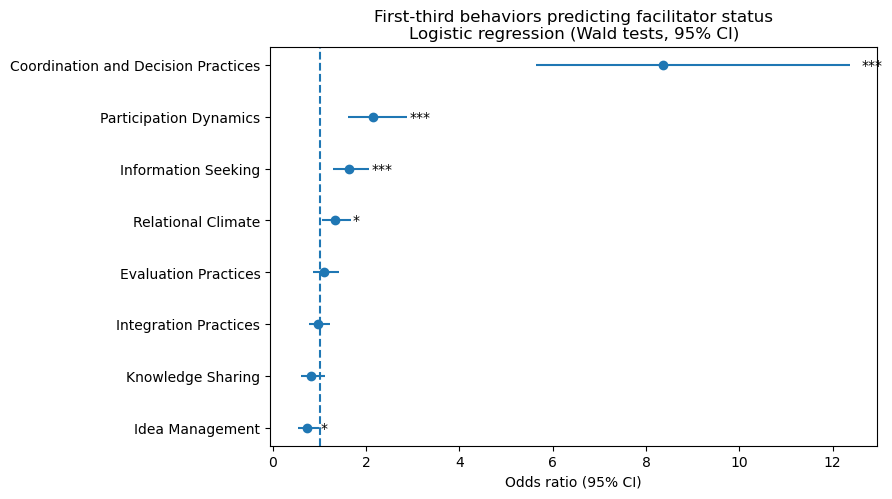

In [4]:
import os, json, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -------------------------
# CONFIG (match your earlier settings)
# -------------------------
BASE_DIR = '/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data' # same as before
OUTCOME = "is_facilitator"
STANDARDIZE = True  # OR per 1 SD increase

# df_indiv must already exist from your earlier chunk:
# columns: session_id, speaker, + code columns

# -------------------------
# Helpers
# -------------------------
def safe_load_json(path: str):
    with open(path, "r") as f:
        return json.load(f)

def normalize_name(s: str) -> str:
    """Normalize speaker names so outcomes & session speakers match."""
    if s is None:
        return ""
    s = str(s)
    # drop affiliations like "Marcel Schreier - UWisc Madison"
    s = re.split(r"\s+-\s+", s)[0]
    # collapse whitespace and strip
    s = re.sub(r"\s+", " ", s).strip()
    # lowercase for robust matching
    return s.lower()

def is_session_outcomes_file(path: str) -> bool:
    return os.path.basename(path).endswith("_session_outcomes.json")

def extract_session_key(session_id: str) -> str:
    """
    Your df_indiv session_id looks like:
      2020NES__session_data__2020_11_05_NES_S1
    We want the trailing key:
      2020_11_05_NES_S1
    """
    return str(session_id).split("__")[-1]

# -------------------------
# Build: session_key -> set(facilitators)
# -------------------------
outcomes_paths = glob.glob(os.path.join(BASE_DIR, "**", "*_session_outcomes.json"), recursive=True)

sessionkey_to_facilitators = {}
outcomes_loaded = 0

for p in outcomes_paths:
    try:
        obj = safe_load_json(p)
    except Exception:
        continue

    # outcomes file structure: dict keyed by session_key -> dict with 'facilitators'
    if not isinstance(obj, dict):
        continue

    outcomes_loaded += 1

    for session_key, entry in obj.items():
        if not isinstance(entry, dict):
            continue

        facs = entry.get("facilitators", None)
        if facs is None:
            continue

        if isinstance(facs, str):
            fac_list = [facs]
        elif isinstance(facs, list):
            fac_list = facs
        else:
            continue

        fac_norm = {normalize_name(x) for x in fac_list if normalize_name(x)}
        if not fac_norm:
            continue

        sessionkey_to_facilitators.setdefault(session_key, set()).update(fac_norm)

print("=== OUTCOMES LABEL COVERAGE ===")
print("Outcomes files found:", len(outcomes_paths))
print("Outcomes files loaded:", outcomes_loaded)
print("Session keys with facilitator labels:", len(sessionkey_to_facilitators))

# -------------------------
# Attach labels to df_indiv
# -------------------------
df_indiv = df_indiv.copy()
df_indiv["session_key"] = df_indiv["session_id"].apply(extract_session_key)
df_indiv["speaker_norm"] = df_indiv["speaker"].apply(normalize_name)

def label_facilitator(row):
    facs = sessionkey_to_facilitators.get(row["session_key"], None)
    if facs is None:
        return np.nan  # unknown label for this session
    return 1 if row["speaker_norm"] in facs else 0

df_indiv[OUTCOME] = df_indiv.apply(label_facilitator, axis=1)

# Report label join success
n_total = len(df_indiv)
n_labeled = df_indiv[OUTCOME].notna().sum()
n_missing = n_total - n_labeled

print("\n=== LABEL JOIN REPORT ===")
print("Rows in df_indiv:", n_total)
print("Rows with facilitator label:", n_labeled)
print("Rows missing label (session not in outcomes):", n_missing)

# If you want, see which sessions are missing:
if n_missing > 0:
    missing_sessions = df_indiv.loc[df_indiv[OUTCOME].isna(), "session_key"].value_counts().head(20)
    print("\nTop missing session_keys:")
    display(missing_sessions)

# Drop unlabeled rows for modeling
df_model = df_indiv.dropna(subset=[OUTCOME]).copy()
df_model[OUTCOME] = df_model[OUTCOME].astype(int)

print("\n=== Facilitator class balance (labeled rows) ===")
print(df_model[OUTCOME].value_counts())

# -------------------------
# Logistic regression
# -------------------------
feature_cols = [c for c in df_model.columns if c not in ["session_id", "speaker", "session_key", "speaker_norm", OUTCOME]]

X = df_model[feature_cols].astype(float)
y = df_model[OUTCOME].astype(int)

if STANDARDIZE:
    X = (X - X.mean()) / (X.std(ddof=0).replace(0, np.nan))
    X = X.fillna(0.0)

X = sm.add_constant(X)

model = sm.Logit(y, X)
res = model.fit(disp=False)

beta = res.params
se = res.bse
pvals = res.pvalues

OR = np.exp(beta)
CI_low = np.exp(beta - 1.96 * se)
CI_high = np.exp(beta + 1.96 * se)

out = (
    pd.DataFrame({
        "feature": beta.index,
        "beta": beta.values,
        "se": se.values,
        "p": pvals.values,
        "OR": OR.values,
        "CI_low": CI_low.values,
        "CI_high": CI_high.values,
    })
    .query("feature != 'const'")
    .sort_values("OR", ascending=True)
    .reset_index(drop=True)
)

out["sig_95CI"] = ~((out["CI_low"] <= 1.0) & (out["CI_high"] >= 1.0))

print("\n=== Logistic regression results (odds ratios) ===")
display(out[["feature", "OR", "CI_low", "CI_high", "p", "sig_95CI"]])

# -------------------------
# Forest plot
# -------------------------
fig_h = max(4, 0.45 * len(out) + 1.5)
plt.figure(figsize=(9, fig_h))

ypos = np.arange(len(out))
plt.hlines(y=ypos, xmin=out["CI_low"], xmax=out["CI_high"])
plt.plot(out["OR"], ypos, "o")
plt.axvline(1.0, linestyle="--")

plt.yticks(ypos, out["feature"])
plt.xlabel("Odds ratio (95% CI)")
plt.title("First-third behaviors predicting facilitator status\nLogistic regression (Wald tests, 95% CI)")

for i, row in out.iterrows():
    if row["p"] < 0.001:
        star = "***"
    elif row["p"] < 0.01:
        star = "**"
    elif row["p"] < 0.05:
        star = "*"
    else:
        star = ""
    if star:
        plt.text(row["CI_high"] * 1.02, i, star, va="center")

plt.tight_layout()
plt.show()

In [5]:
# assuming you already have:
#   res = statsmodels Logit (or GLM Binomial) fitted result

import pandas as pd
import numpy as np

summary = pd.DataFrame({
    "coef": res.params,
    "se": res.bse,
    "z": res.tvalues,          # Wald z-stat
    "p": res.pvalues,          # Wald p-value
    "OR": np.exp(res.params),
    "CI_low": np.exp(res.conf_int()[0]),
    "CI_high": np.exp(res.conf_int()[1]),
})

# drop intercept if you want
summary = summary.drop(index=[i for i in summary.index if "Intercept" in str(i) or "const" in str(i)], errors="ignore")

summary = summary.sort_values("p")
display(summary)

,coef,se,z,p,OR,CI_low,CI_high
Coordination and Decision Practices,2.123007,0.200017,10.614148,2.561196e-26,8.356224,5.646191,12.367007
Participation Dynamics,0.767752,0.147177,5.216522,1.823138e-07,2.154917,1.614928,2.875463
Information Seeking,0.489249,0.120563,4.058033,4.948774e-05,1.631092,1.287819,2.065865
Relational Climate,0.279898,0.119391,2.344388,1.905833e-02,1.322995,1.046966,1.671797
Idea Management,-0.318995,0.160941,-1.982060,4.747251e-02,0.726879,0.530236,0.996450
Knowledge Sharing,-0.200380,0.159726,-1.254529,2.096498e-01,0.818419,0.598435,1.119269
Evaluation Practices,0.093874,0.130639,0.718579,4.724005e-01,1.098422,0.850294,1.418957
Integration Practices,-0.023406,0.115228,-0.203125,8.390370e-01,0.976866,0.779385,1.224384


In [6]:
# feature columns (exclude obvious id columns)
id_cols = {"session_id", "speaker", "session_key", "speaker_norm", "is_facilitator"}
code_cols = [c for c in df_indiv.columns if c not in id_cols]

# force numeric; non-numeric -> NaN
Xnum = df_indiv[code_cols].apply(pd.to_numeric, errors="coerce")

# now these work
print("Top max values:")
print(Xnum.max().sort_values(ascending=False).head(10))

sample = Xnum.stack().dropna()
print("\nFraction near-integers:")
print((np.isclose(sample, np.round(sample))).mean())

print("\nNon-numeric columns that got coerced (had NaNs after coercion):")
bad = Xnum.isna().any()
print(bad[bad].index.tolist())

Top max values:
code
Knowledge Sharing                      12.250000
Coordination and Decision Practices     8.566667
Relational Climate                      7.516667
Participation Dynamics                  7.333333
Idea Management                         7.050000
Evaluation Practices                    5.666667
Information Seeking                     4.866667
Integration Practices                   3.000000
dtype: float64

Fraction near-integers:
0.5379917512690355

Non-numeric columns that got coerced (had NaNs after coercion):
[]


## Slide 5 - First Part

Found outcome files: 8
Outcomes files loaded: 8
Sessions with teams: 123
Unique people with team membership: 219
Member->team links added: 310

=== df_feat built (person x session) ===
df_feat shape: (1576, 10)


code,session_id,speaker,Coordination and Decision Practices,Evaluation Practices,Idea Management,Information Seeking,Integration Practices,Knowledge Sharing,Participation Dynamics,Relational Climate
0,2020NES__session_data__2020_11_05_NES_S1,Alissa Park,6.183333,1.083333,3.883333,2.533333,0.0,9.333333,0.000000,0.883333
1,2020NES__session_data__2020_11_05_NES_S1,Chris Gorski,0.000000,0.000000,0.000000,0.000000,0.0,0.116667,0.000000,0.000000
2,2020NES__session_data__2020_11_05_NES_S1,Emily Ryan,0.000000,0.950000,0.366667,0.783333,0.0,1.366667,0.000000,0.166667
3,2020NES__session_data__2020_11_05_NES_S1,Fateme Rezaei,0.000000,0.000000,0.000000,0.833333,0.0,0.916667,0.833333,0.000000
4,2020NES__session_data__2020_11_05_NES_S1,Gary Moore,0.000000,0.000000,0.400000,0.166667,0.0,0.400000,0.000000,0.000000



=== Outcome counts (on_team_any) ===
on_team_any
0    765
1    811
Name: count, dtype: int64
Positive rate: 0.5145939086294417
Sanity: matches in first 200 speakers: 112

=== Slide 5 sanity checks ===
Rows used: 1576
Num features: 8

=== Slide 5 results (ridge OR per 1 SD; bootstrap 95% CI) ===


,OR,CI_low,CI_high,CI_excludes_1
Knowledge Sharing,1.228040,1.031264,1.519356,True
Information Seeking,1.106260,0.970228,1.286359,False
Evaluation Practices,1.067991,0.915688,1.254585,False
Idea Management,1.061690,0.900555,1.264676,False
Integration Practices,1.044251,0.937473,1.179101,False
Relational Climate,1.028070,0.884511,1.202208,False
Participation Dynamics,0.615298,0.429126,0.787473,True
Coordination and Decision Practices,0.339273,0.235845,0.456850,True


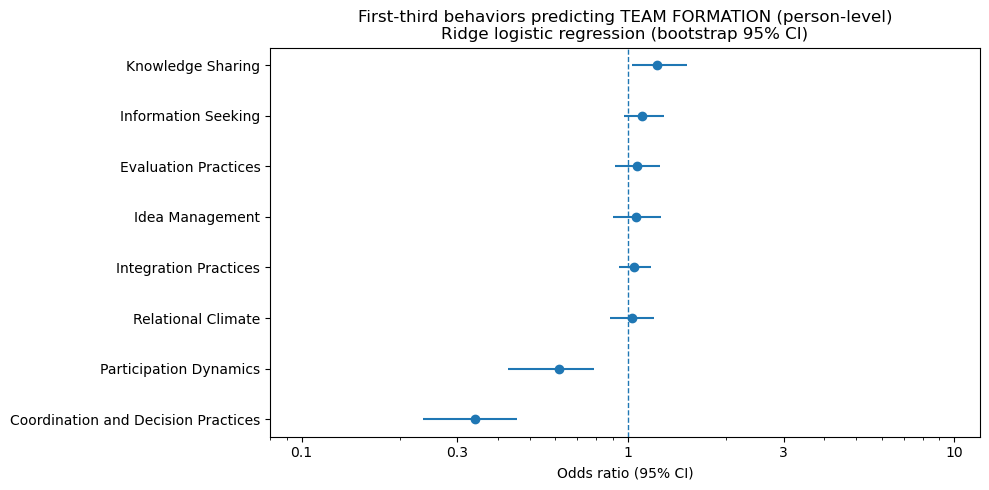

In [7]:
# ============================================================
# SLIDE 5 (UPDATED): Person-level TEAM FORMATION
# Uses df_long (from your "Slide 4" person-level build)
# Builds PERSON_TO_TEAM from ALL *_session_outcomes.json (across conferences)
# Creates on_team_any correctly (name-normalized lookup)
# Ridge logistic + stratified bootstrap OR CIs + forest plot
# ============================================================

import os, glob, json, re
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.ticker import FixedLocator, FuncFormatter

# -------------------------
# CONFIG
# -------------------------
BASE_DIR = "/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data"

DF_LONG_NAME = "df_long"   # must exist
VALUE_COL = "value"        # minutes if USE_TIME=True, else counts
OUTCOME_COL = "on_team_any"

C_VAL = 1.0
N_BOOT = 1000
RNG_SEED = 0

# -------------------------
# Helpers
# -------------------------
def normalize_name(s: str) -> str:
    """Normalize names for robust matching between outcomes roster and speakers."""
    if s is None:
        return ""
    s = str(s)
    s = re.split(r"\s+-\s+", s)[0]          # drop affiliations like "Name - Uni"
    s = re.sub(r"\s+", " ", s).strip()      # collapse whitespace
    return s.lower()

def safe_load_json(path: str):
    with open(path, "r") as f:
        return json.load(f)

# -------------------------
# 1) Build PERSON_TO_TEAM from ALL session_outcomes
# -------------------------
outcome_paths = glob.glob(os.path.join(BASE_DIR, "**", "*_session_outcomes.json"), recursive=True)
print("Found outcome files:", len(outcome_paths))

PERSON_TO_TEAM = defaultdict(set)

files_loaded = 0
sessions_with_teams = 0
members_added = 0

for path in outcome_paths:
    try:
        outcomes = safe_load_json(path)
    except Exception:
        continue
    if not isinstance(outcomes, dict):
        continue

    files_loaded += 1

    for session_key, entry in outcomes.items():
        if not isinstance(entry, dict):
            continue

        teams = entry.get("teams", None)
        if not isinstance(teams, dict) or len(teams) == 0:
            continue

        sessions_with_teams += 1

        for team_id, team_info in teams.items():
            if not isinstance(team_info, dict):
                continue
            members = team_info.get("members", [])
            if not isinstance(members, list):
                continue

            for m in members:
                nm = normalize_name(m)
                if nm:
                    before = len(PERSON_TO_TEAM[nm])
                    PERSON_TO_TEAM[nm].add(str(team_id))
                    after = len(PERSON_TO_TEAM[nm])
                    if after > before:
                        members_added += 1

# freeze to plain dict (nice for printing/debug)
PERSON_TO_TEAM = dict(PERSON_TO_TEAM)

print("Outcomes files loaded:", files_loaded)
print("Sessions with teams:", sessions_with_teams)
print("Unique people with team membership:", len(PERSON_TO_TEAM))
print("Member->team links added:", members_added)

# -------------------------
# 2) Build df_feat (person x session wide) from df_long
# -------------------------
if DF_LONG_NAME not in globals():
    raise NameError(f"{DF_LONG_NAME} not found. Run the df_long construction cell first.")

df_long_local = globals()[DF_LONG_NAME].copy()

required = {"session_id", "speaker", "code", VALUE_COL}
missing = required - set(df_long_local.columns)
if missing:
    raise ValueError(f"{DF_LONG_NAME} missing {missing}. Has: {list(df_long_local.columns)}")

df_long_local["speaker"] = df_long_local["speaker"].astype(str).str.strip()
df_long_local["code"] = df_long_local["code"].astype(str).str.strip()
df_long_local = df_long_local[(df_long_local["speaker"] != "") & (df_long_local["code"] != "")].copy()

df_ps = (
    df_long_local
    .groupby(["session_id", "speaker", "code"], as_index=False)[VALUE_COL]
    .sum()
)

df_feat = (
    df_ps
    .pivot_table(index=["session_id", "speaker"], columns="code", values=VALUE_COL, fill_value=0.0)
    .reset_index()
)

print("\n=== df_feat built (person x session) ===")
print("df_feat shape:", df_feat.shape)
display(df_feat.head())

# -------------------------
# 3) Create on_team_any (CORRECT: normalize df_feat speakers before lookup)
# -------------------------
def person_on_team_any(person_name: str) -> int:
    key = normalize_name(person_name)
    team_ids = PERSON_TO_TEAM.get(key, set())
    return int(len(team_ids) > 0)

df_feat[OUTCOME_COL] = df_feat["speaker"].apply(person_on_team_any).astype(int)

vc = df_feat[OUTCOME_COL].value_counts().sort_index()
print("\n=== Outcome counts (on_team_any) ===")
print(vc)
print("Positive rate:", float(df_feat[OUTCOME_COL].mean()))

# Quick matching sanity check
sample_n = min(200, len(df_feat))
hits = sum(normalize_name(s) in PERSON_TO_TEAM for s in df_feat["speaker"].head(sample_n))
print(f"Sanity: matches in first {sample_n} speakers:", hits)

if df_feat[OUTCOME_COL].nunique() < 2:
    raise ValueError(
        "Degenerate outcome: everyone is on a team or no one is.\n"
        "This usually means outcomes 'teams/members' names don't match df_long speakers.\n"
        "Check the 'hits' sanity print and inspect normalize_name rules."
    )

# -------------------------
# 4) Build X/y
# -------------------------
DROP_COLS = {"session_id", "speaker", OUTCOME_COL}
FEATURES = [c for c in df_feat.columns if c not in DROP_COLS]

X_df = df_feat[FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0.0)

# drop constant columns
zero_var = [c for c in X_df.columns if np.isclose(X_df[c].var(ddof=0), 0.0)]
if zero_var:
    X_df = X_df.drop(columns=zero_var)
    FEATURES = [c for c in FEATURES if c not in zero_var]

X = X_df.values
y = df_feat[OUTCOME_COL].values

print("\n=== Slide 5 sanity checks ===")
print("Rows used:", len(y))
print("Num features:", len(FEATURES))

# -------------------------
# 5) Ridge logistic (OR per 1 SD increase because StandardScaler)
# -------------------------
ridge = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    LogisticRegression(
        penalty="l2",
        C=C_VAL,
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=RNG_SEED,
    )
)
ridge.fit(X, y)

OR_point = np.exp(ridge.named_steps["logisticregression"].coef_.ravel())

# -------------------------
# 6) Stratified bootstrap OR CIs
# -------------------------
rng = np.random.default_rng(RNG_SEED)

idx_pos = np.where(y == 1)[0]
idx_neg = np.where(y == 0)[0]
n_pos, n_neg = len(idx_pos), len(idx_neg)

boot_or = np.zeros((N_BOOT, len(FEATURES)), dtype=float)

for b in range(N_BOOT):
    samp_idx = np.concatenate([
        rng.choice(idx_pos, size=n_pos, replace=True),
        rng.choice(idx_neg, size=n_neg, replace=True),
    ])

    Xb, yb = X[samp_idx], y[samp_idx]

    mb = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        LogisticRegression(
            penalty="l2",
            C=C_VAL,
            solver="lbfgs",
            max_iter=5000,
            class_weight="balanced",
            random_state=RNG_SEED,
        )
    )
    mb.fit(Xb, yb)
    boot_or[b, :] = np.exp(mb.named_steps["logisticregression"].coef_.ravel())

CI_low = np.quantile(boot_or, 0.025, axis=0)
CI_high = np.quantile(boot_or, 0.975, axis=0)

out = pd.DataFrame({"OR": OR_point, "CI_low": CI_low, "CI_high": CI_high}, index=FEATURES)
out["CI_excludes_1"] = (out["CI_low"] > 1.0) | (out["CI_high"] < 1.0)
out_sorted = out.sort_values("OR", ascending=False)

print("\n=== Slide 5 results (ridge OR per 1 SD; bootstrap 95% CI) ===")
display(out_sorted)

# -------------------------
# 7) Forest plot
# -------------------------
plot_df = out_sorted.sort_values("OR").copy()
eps = 1e-12
plot_df[["CI_low", "OR", "CI_high"]] = plot_df[["CI_low", "OR", "CI_high"]].clip(lower=eps)

fig_h = max(5, 0.35 * len(plot_df) + 2)
fig, ax = plt.subplots(figsize=(10, fig_h))

ypos = np.arange(len(plot_df))
ax.hlines(y=ypos, xmin=plot_df["CI_low"], xmax=plot_df["CI_high"])
ax.plot(plot_df["OR"], ypos, "o")
ax.axvline(1.0, linestyle="--", linewidth=1)

ax.set_xscale("log")
ax.set_xlim(0.08, 12)
tick_vals = [0.1, 0.3, 1, 3, 10]
ax.xaxis.set_major_locator(FixedLocator(tick_vals))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Odds ratio (95% CI)")
ax.set_title("First-third behaviors predicting TEAM FORMATION (person-level)\nRidge logistic regression (bootstrap 95% CI)")

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# SLIDE 5B (FIX): rebuild X and y from df_feat (same rows),
# refit ridge on DataFrame, then compute approximate Wald p-values
# ============================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

OUTCOME_COL = "on_team_any"   # Slide 5 outcome

# 1) Rebuild the EXACT feature list the model should use
DROP_COLS = {"session_id", "speaker", OUTCOME_COL}
FEATURES = [c for c in df_feat.columns if c not in DROP_COLS]

X_df = df_feat[FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0.0)

# drop constant columns (must match what you do in the main Slide 5 fit)
zero_var = [c for c in X_df.columns if np.isclose(X_df[c].var(ddof=0), 0.0)]
if zero_var:
    X_df = X_df.drop(columns=zero_var)
    FEATURES = [c for c in FEATURES if c not in zero_var]

# 2) Rebuild y from df_feat (same row count)
y = df_feat[OUTCOME_COL].astype(int).values

print("X shape:", X_df.shape, "| y shape:", y.shape)
print("Outcome counts:\n", pd.Series(y).value_counts().sort_index())

# 3) Fit ridge using DataFrame (keeps feature names)
ridge_df = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    LogisticRegression(
        penalty="l2",
        C=C_VAL,
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=RNG_SEED,
    )
)
ridge_df.fit(X_df, y)

# 4) Wald-style p-values (approx)
coef = ridge_df.named_steps["logisticregression"].coef_.ravel()
X_std = ridge_df.named_steps["standardscaler"].transform(X_df)
p_hat = ridge_df.predict_proba(X_df)[:, 1]

w = p_hat * (1 - p_hat)
XtWX = X_std.T @ (X_std * w[:, None])

lambda_ridge = 1.0 / C_VAL
XtWX_pen = XtWX + lambda_ridge * np.eye(XtWX.shape[0])
cov_beta = np.linalg.inv(XtWX_pen)
se = np.sqrt(np.diag(cov_beta))

z = coef / se
p = 2 * (1 - stats.norm.cdf(np.abs(z)))

wald_df = pd.DataFrame(
    {"OR": np.exp(coef), "z": z, "p_value": p},
    index=X_df.columns
).sort_values("OR", ascending=False)

wald_df["sig_p05"] = wald_df["p_value"] < 0.05

print("\n=== Slide 5 Wald p-values (approx; ridge logistic) ===")
display(wald_df)

X shape: (1576, 8) | y shape: (1576,)
Outcome counts:
 0    765
1    811
Name: count, dtype: int64

=== Slide 5 Wald p-values (approx; ridge logistic) ===


,OR,z,p_value,sig_p05
code,,,,
Knowledge Sharing,1.228040,2.237408,2.525968e-02,True
Information Seeking,1.106260,1.487511,1.368799e-01,False
Evaluation Practices,1.067991,0.969395,3.323482e-01,False
Idea Management,1.061690,0.686822,4.921949e-01,False
Integration Practices,1.044251,0.676860,4.984947e-01,False
Relational Climate,1.028070,0.384325,7.007375e-01,False
Participation Dynamics,0.615298,-4.001319,6.299025e-05,True
Coordination and Decision Practices,0.339273,-7.344343,2.067235e-13,True


## Slide 6

In [8]:
# ============================================================
# SLIDE 4 (REBUILD): Create person-level long df for Slide 6A
# Produces: df_long_person with columns:
#   session_id, speaker, when, code, value
# ============================================================

import pandas as pd
import numpy as np

# --- pick the best existing person x session wide df in memory ---
# You said you have df_feat already from Slide 5 (person x session).
# If not, this will search for a df that has session_id + speaker and multiple code columns.

def find_person_wide_df():
    snap = list(globals().items())
    cands = []
    for name, obj in snap:
        if isinstance(obj, pd.DataFrame):
            cols = set(obj.columns)
            if {"session_id", "speaker"}.issubset(cols):
                # heuristic: at least 5 behavior columns
                non_id = cols - {"session_id", "speaker", "session_key", "speaker_norm", "is_facilitator", "when"}
                if len(non_id) >= 5:
                    cands.append((name, len(non_id)))
    cands = sorted(cands, key=lambda x: x[1], reverse=True)
    return cands

cands = find_person_wide_df()
print("Person-wide candidates:", cands[:5])

if "df_feat" in globals() and isinstance(globals()["df_feat"], pd.DataFrame) and {"session_id","speaker"}.issubset(globals()["df_feat"].columns):
    wide = globals()["df_feat"].copy()
    src_name = "df_feat"
elif len(cands) > 0:
    src_name = cands[0][0]
    wide = globals()[src_name].copy()
else:
    raise ValueError(
        "Couldn't find a person-level wide dataframe (needs session_id + speaker + behavior columns).\n"
        "If you previously built df_feat (person x session) for Slide 5, re-run that cell first."
    )

print(f"Using person-wide df: {src_name} | shape={wide.shape}")

# --- ensure a 'when' column exists (since Slide 6A filters WHEN_FILTER) ---
# If you only have beginning-third features in this df already, label it as 'beginning'.
if "when" not in wide.columns:
    wide["when"] = "beginning"

# --- melt wide -> long ---
id_cols = ["session_id", "speaker", "when"]
drop_cols = {"session_key", "speaker_norm", "is_facilitator"}  # ignore metadata if present
value_vars = [c for c in wide.columns if c not in set(id_cols) and c not in drop_cols]

df_long_person = wide.melt(
    id_vars=id_cols,
    value_vars=value_vars,
    var_name="code",
    value_name="value"
)

df_long_person["code"] = df_long_person["code"].astype(str).str.strip()
df_long_person["speaker"] = df_long_person["speaker"].astype(str).str.strip()
df_long_person["value"] = pd.to_numeric(df_long_person["value"], errors="coerce").fillna(0.0)

print("Built df_long_person:", df_long_person.shape)
display(df_long_person.head())

# leave it in globals for Slide 6A

Person-wide candidates: [('df_feat', 9), ('df_indiv', 8), ('df_model', 8)]
Using person-wide df: df_feat | shape=(1576, 11)
Built df_long_person: (14184, 5)


,session_id,speaker,when,code,value
0,2020NES__session_data__2020_11_05_NES_S1,Alissa Park,beginning,Coordination and Decision Practices,6.183333
1,2020NES__session_data__2020_11_05_NES_S1,Chris Gorski,beginning,Coordination and Decision Practices,0.000000
2,2020NES__session_data__2020_11_05_NES_S1,Emily Ryan,beginning,Coordination and Decision Practices,0.000000
3,2020NES__session_data__2020_11_05_NES_S1,Fateme Rezaei,beginning,Coordination and Decision Practices,0.000000
4,2020NES__session_data__2020_11_05_NES_S1,Gary Moore,beginning,Coordination and Decision Practices,0.000000


=== df_feat built (PERSON x SESSION) ===
df_feat shape: (1576, 11)


code,session_id,speaker,Coordination and Decision Practices,Evaluation Practices,Idea Management,Information Seeking,Integration Practices,Knowledge Sharing,Participation Dynamics,Relational Climate,on_team_any
0,2020NES__session_data__2020_11_05_NES_S1,Alissa Park,6.183333,1.083333,3.883333,2.533333,0.0,9.333333,0.000000,0.883333,0.0
1,2020NES__session_data__2020_11_05_NES_S1,Chris Gorski,0.000000,0.000000,0.000000,0.000000,0.0,0.116667,0.000000,0.000000,1.0
2,2020NES__session_data__2020_11_05_NES_S1,Emily Ryan,0.000000,0.950000,0.366667,0.783333,0.0,1.366667,0.000000,0.166667,1.0
3,2020NES__session_data__2020_11_05_NES_S1,Fateme Rezaei,0.000000,0.000000,0.000000,0.833333,0.0,0.916667,0.833333,0.000000,0.0
4,2020NES__session_data__2020_11_05_NES_S1,Gary Moore,0.000000,0.000000,0.400000,0.166667,0.0,0.400000,0.000000,0.000000,1.0



Found outcome files: 8
Session keys with funded label: 123
Funding key usage:
  funded_status: 123

=== Join report ===
Rows in df_feat: 1576
Rows with label: 1245
Rows missing label: 331

Outcome counts (funded_any):
funded_any
0    786
1    459
Name: count, dtype: int64
Positive rate: 0.3686746987951807

=== Slide 6A results (INDIVIDUAL-level; ridge OR per 1 SD; bootstrap 95% CI) ===


,OR,CI_low,CI_high,CI_excludes_1
Idea Management,1.342519,1.138565,1.638292,True
Relational Climate,1.070830,0.933752,1.226997,False
Information Seeking,1.044539,0.910603,1.196013,False
Integration Practices,1.011896,0.886612,1.139828,False
on_team_any,1.003458,0.889879,1.127688,False
Coordination and Decision Practices,0.958964,0.784991,1.148349,False
Participation Dynamics,0.952307,0.779276,1.131730,False
Evaluation Practices,0.923082,0.793611,1.059208,False
Knowledge Sharing,0.864201,0.702262,1.031497,False


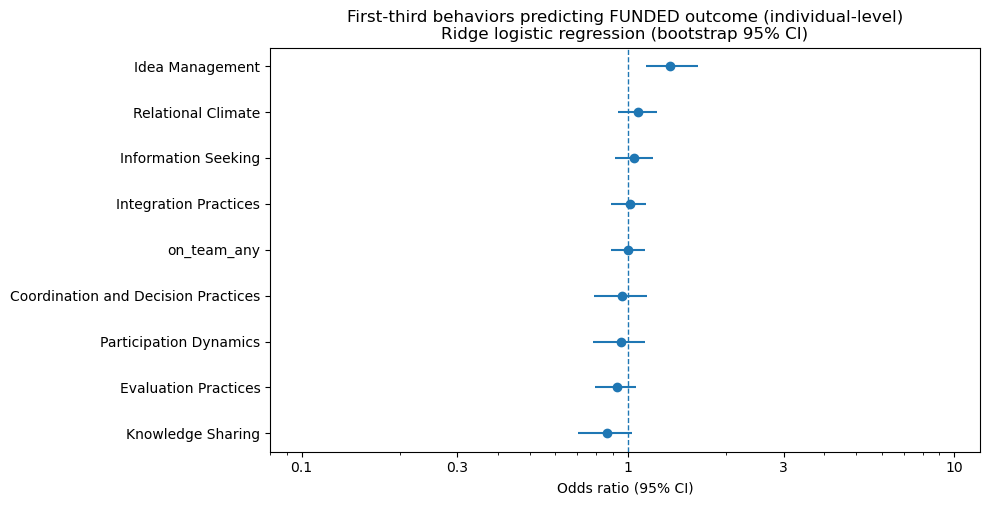


(df_labeled is INDIVIDUAL-level and defined.)


In [9]:
# ============================================================
# SLIDE 6A (INDIVIDUAL-LEVEL): FUNDING outcome
# - Uses df_long_person: ['session_id','speaker','when','code','value']
# - Loads funding labels from *_session_outcomes.json (key: funded_status)
# - Joins session funding onto each person-row
# - Ridge logistic + stratified bootstrap OR CIs + forest plot
# ============================================================

import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.ticker import FixedLocator, FuncFormatter

# ----------------------------
# CONFIG
# ----------------------------
BASE_DIR = "/Users/maxchalekson/Northwestern University/Summer-2025/NICO/NICO Research/gemini_data_analysis/data"

WHEN_FILTER = "beginning"
OUTCOME_COL = "funded_any"
C_VAL = 1.0
N_BOOT = 1000
RNG_SEED = 0

IGNORE_CODES = {"None", "Other", ""}

FUNDING_KEYS = [
    "funded_status",  # <-- your schema key
    "funded_any", "funded", "is_funded", "funding",
    "outcome_funded", "proposal_funded", "successful", "success"
]

# ----------------------------
# Helpers
# ----------------------------
def safe_load_json(path: str):
    with open(path, "r") as f:
        return json.load(f)

def extract_session_key(session_id: str) -> str:
    return str(session_id).split("__")[-1]

def normalize_to_binary(val):
    if val is None:
        return None
    if isinstance(val, bool):
        return int(val)
    if isinstance(val, (int, float)) and np.isfinite(val):
        return int(val != 0)
    if isinstance(val, str):
        v = val.strip().lower()
        if v in {"funded","yes","y","true","successful","success","1"}:
            return 1
        if v in {"not funded","no","n","false","unsuccessful","fail","0"}:
            return 0
    return None

def find_first_key_recursive(obj, keys):
    if isinstance(obj, dict):
        for k in keys:
            if k in obj:
                return k, obj.get(k)
        for v in obj.values():
            fk, fv = find_first_key_recursive(v, keys)
            if fk is not None:
                return fk, fv
    elif isinstance(obj, list):
        for item in obj:
            fk, fv = find_first_key_recursive(item, keys)
            if fk is not None:
                return fk, fv
    return None, None

# ----------------------------
# 0) Input: df_long_person must exist
# ----------------------------
if "df_long_person" not in globals():
    raise NameError("df_long_person not found. Run your person-level rebuild/melt cell first.")

df_long_local = df_long_person.copy()

required = {"session_id","speaker","when","code","value"}
missing = required - set(df_long_local.columns)
if missing:
    raise ValueError(f"df_long_person missing {missing}. Has: {list(df_long_local.columns)}")

# clean + filter
df_long_local["speaker"] = df_long_local["speaker"].astype(str).str.strip()
df_long_local["code"] = df_long_local["code"].astype(str).str.strip()

df_long_local = df_long_local[(df_long_local["speaker"] != "") & (df_long_local["code"] != "")].copy()
df_long_local = df_long_local[~df_long_local["code"].isin(IGNORE_CODES)].copy()

df_first = df_long_local[df_long_local["when"] == WHEN_FILTER].copy()
if df_first.empty:
    raise ValueError(f"No rows for when == '{WHEN_FILTER}'. Check df_long_person['when']: {df_long_local['when'].unique()}")

# person-session-code aggregate -> PERSON x SESSION wide
df_ps = (
    df_first
    .groupby(["session_id","speaker","code"], as_index=False)["value"]
    .sum()
)

df_feat = (
    df_ps
    .pivot_table(index=["session_id","speaker"], columns="code", values="value", fill_value=0.0)
    .reset_index()
)

print("=== df_feat built (PERSON x SESSION) ===")
print("df_feat shape:", df_feat.shape)
display(df_feat.head())

# ----------------------------
# 1) Load funding labels (session-level) from outcomes JSONs
# ----------------------------
outcome_paths = glob.glob(os.path.join(BASE_DIR, "**", "*_session_outcomes.json"), recursive=True)
print("\nFound outcome files:", len(outcome_paths))

sessionkey_to_funded = {}
key_hits = {k: 0 for k in FUNDING_KEYS}

for path in outcome_paths:
    try:
        outcomes = safe_load_json(path)
    except Exception:
        continue
    if not isinstance(outcomes, dict):
        continue

    for session_key, entry in outcomes.items():
        if not isinstance(entry, dict):
            continue

        found_key, found_val = find_first_key_recursive(entry, FUNDING_KEYS)
        if found_key is None:
            continue

        b = normalize_to_binary(found_val)
        if b is None:
            continue

        key_hits[found_key] += 1
        sessionkey_to_funded[str(session_key)] = int(b)

print("Session keys with funded label:", len(sessionkey_to_funded))
print("Funding key usage:")
for k, v in sorted(key_hits.items(), key=lambda kv: kv[1], reverse=True):
    if v:
        print(f"  {k}: {v}")

if len(sessionkey_to_funded) == 0:
    raise ValueError("No funded labels extracted. Confirm outcomes schema / keys.")

# ----------------------------
# 2) Join funding onto each person-row (via session_key)
# ----------------------------
df_labeled = df_feat.copy()
df_labeled["session_key"] = df_labeled["session_id"].apply(extract_session_key)
df_labeled[OUTCOME_COL] = df_labeled["session_key"].map(sessionkey_to_funded)

print("\n=== Join report ===")
print("Rows in df_feat:", len(df_feat))
print("Rows with label:", int(df_labeled[OUTCOME_COL].notna().sum()))
print("Rows missing label:", int(df_labeled[OUTCOME_COL].isna().sum()))

df_labeled = df_labeled.dropna(subset=[OUTCOME_COL]).copy()
df_labeled[OUTCOME_COL] = df_labeled[OUTCOME_COL].astype(int)

print("\nOutcome counts (funded_any):")
print(df_labeled[OUTCOME_COL].value_counts().sort_index())
print("Positive rate:", float(df_labeled[OUTCOME_COL].mean()))

if df_labeled[OUTCOME_COL].nunique() < 2:
    raise ValueError("Degenerate outcome after join (only one class). Can't fit model.")

# ----------------------------
# 3) Ridge logistic + stratified bootstrap OR CIs
# ----------------------------
DROP_COLS = {"session_id","session_key","speaker",OUTCOME_COL}
FEATURES = [c for c in df_labeled.columns if c not in DROP_COLS]

X_df = df_labeled[FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0.0)
zero_var = [c for c in X_df.columns if np.isclose(X_df[c].var(ddof=0), 0.0)]
if zero_var:
    X_df = X_df.drop(columns=zero_var)
    FEATURES = [c for c in FEATURES if c not in zero_var]

X = X_df.values
y = df_labeled[OUTCOME_COL].values

ridge = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        C=C_VAL,
        max_iter=5000,
        random_state=RNG_SEED,
    )
)
ridge.fit(X, y)
OR_point = np.exp(ridge.named_steps["logisticregression"].coef_.ravel())

rng = np.random.default_rng(RNG_SEED)
idx_pos = np.where(y == 1)[0]
idx_neg = np.where(y == 0)[0]

boot_or = np.zeros((N_BOOT, len(FEATURES)), dtype=float)
for b in range(N_BOOT):
    samp_idx = np.concatenate([
        rng.choice(idx_pos, size=len(idx_pos), replace=True),
        rng.choice(idx_neg, size=len(idx_neg), replace=True),
    ])
    Xb, yb = X[samp_idx], y[samp_idx]

    mb = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            class_weight="balanced",
            C=C_VAL,
            max_iter=5000,
            random_state=RNG_SEED,
        )
    )
    mb.fit(Xb, yb)
    boot_or[b] = np.exp(mb.named_steps["logisticregression"].coef_.ravel())

CI_low = np.quantile(boot_or, 0.025, axis=0)
CI_high = np.quantile(boot_or, 0.975, axis=0)

results = pd.DataFrame({"OR": OR_point, "CI_low": CI_low, "CI_high": CI_high}, index=FEATURES)
results["CI_excludes_1"] = (results["CI_low"] > 1.0) | (results["CI_high"] < 1.0)
results = results.sort_values("OR", ascending=False)

print("\n=== Slide 6A results (INDIVIDUAL-level; ridge OR per 1 SD; bootstrap 95% CI) ===")
display(results)

# ----------------------------
# 4) Forest plot
# ----------------------------
plot_df = results.sort_values("OR").copy()
eps = 1e-12
plot_df[["OR","CI_low","CI_high"]] = plot_df[["OR","CI_low","CI_high"]].clip(lower=eps)

fig_h = max(5, 0.35 * len(plot_df) + 2)
fig, ax = plt.subplots(figsize=(10, fig_h))
ypos = np.arange(len(plot_df))

ax.hlines(y=ypos, xmin=plot_df["CI_low"], xmax=plot_df["CI_high"])
ax.plot(plot_df["OR"], ypos, "o")
ax.axvline(1.0, linestyle="--", linewidth=1)

ax.set_xscale("log")
ax.set_xlim(0.08, 12)
tick_vals = [0.1, 0.3, 1, 3, 10]
ax.xaxis.set_major_locator(FixedLocator(tick_vals))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Odds ratio (95% CI)")
ax.set_title("First-third behaviors predicting FUNDED outcome (individual-level)\nRidge logistic regression (bootstrap 95% CI)")

plt.tight_layout()
plt.show()

print("\n(df_labeled is INDIVIDUAL-level and defined.)")

In [21]:
# ============================================================
# SLIDE 6A (REFERENCE ONLY):
# Plain, unpenalized logistic regression Wald p-values (unstable under imbalance)
# - Uses the SAME predictors as your ridge model (FEATURES)
# - Standardizes predictors (OR per 1 SD)
# - Drops missing rows ONCE (aligned X/y)
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm

# --- assumes you already ran Slide 6A above and have:
# df_labeled, OUTCOME_COL, FEATURES

# 1) Build X and y from the same objects used in ridge
X_df = df_labeled[FEATURES].apply(pd.to_numeric, errors="coerce")
y_s  = df_labeled[OUTCOME_COL].astype(int)

# 2) Standardize X (per 1 SD increase)
X_std = (X_df - X_df.mean(axis=0)) / X_df.std(axis=0, ddof=0)
X_std = X_std.replace([np.inf, -np.inf], np.nan)

# 3) Align and drop missing ONCE
dat = pd.concat([y_s.rename("y"), X_std], axis=1).dropna(axis=0).copy()
y_aligned = dat["y"].astype(int)
X_aligned = dat.drop(columns=["y"])

# 4) Drop constant/near-constant columns (Logit hates them)
const_cols = [c for c in X_aligned.columns if np.isclose(X_aligned[c].var(ddof=0), 0.0)]
if const_cols:
    print("Dropping constant columns for plain Logit:", const_cols)
    X_aligned = X_aligned.drop(columns=const_cols)

# 5) Fit plain Logit
X_sm = sm.add_constant(X_aligned, has_constant="add")

# Note: This can throw if there's separation / singular matrix.
# If it fails, that's not your fault: it's the model screaming "use ridge" (which you did).
res = sm.Logit(y_aligned.values, X_sm.values).fit(disp=False, maxiter=300)

# 6) Wald p-values + ORs
coef = pd.Series(res.params, index=X_sm.columns)
se   = pd.Series(res.bse,    index=X_sm.columns)

z = coef / se
p = 2 * (1 - norm.cdf(np.abs(z)))

wald = pd.DataFrame({
    "OR": np.exp(coef),
    "p": p,
    "z": z,
    "CI_low": np.exp(coef - 1.96 * se),
    "CI_high": np.exp(coef + 1.96 * se),
}, index=X_sm.columns)

wald = wald.drop(index="const", errors="ignore").sort_values("p")

print("=== Slide 6A P-values (reference only): plain, unpenalized Logit Wald tests ===")
display(wald)

# Optional: compact list for speaker notes
speaker = wald.copy()
speaker["OR"] = speaker["OR"].astype(float)
speaker["p"] = speaker["p"].astype(float)

print("\nSpeaker-notes format (OR, p):")
for name, row in speaker.iterrows():
    print(f"{name}: OR ≈ {row['OR']:.2f}, p = {row['p']:.3g}")

=== Slide 6A P-values (reference only): plain, unpenalized Logit Wald tests ===


,OR,p,z,CI_low,CI_high
Coordination and Decision Practices,0.279546,5.269185e-11,-6.563124,0.191048,0.409037
Participation Dynamics,0.635444,1.044455e-03,-3.278270,0.484553,0.833321
Knowledge Sharing,1.218975,6.660630e-02,1.834321,0.986525,1.506195
Idea Management,1.163494,1.428106e-01,1.465404,0.950175,1.424704
Evaluation Practices,1.070062,3.993836e-01,0.842723,0.914134,1.252587
Integration Practices,1.061793,4.100349e-01,0.823832,0.920636,1.224593
Information Seeking,1.022246,7.849307e-01,0.272899,0.872824,1.197248
Relational Climate,0.991061,9.160329e-01,-0.105432,0.838699,1.171102



Speaker-notes format (OR, p):
Coordination and Decision Practices: OR ≈ 0.28, p = 5.27e-11
Participation Dynamics: OR ≈ 0.64, p = 0.00104
Knowledge Sharing: OR ≈ 1.22, p = 0.0666
Idea Management: OR ≈ 1.16, p = 0.143
Evaluation Practices: OR ≈ 1.07, p = 0.399
Integration Practices: OR ≈ 1.06, p = 0.41
Information Seeking: OR ≈ 1.02, p = 0.785
Relational Climate: OR ≈ 0.99, p = 0.916


## Slide 6 - Second Part

Taking in Evey's suggestions to show data "a bit more visually"

(see slide 5 speaker notes w/ Evey)

=== Slide 6B dataset check (SESSION-level) ===
Rows (sessions): 123
Outcome counts (0=unsuccessful, 1=successful):
 0    77
1    46
Name: count, dtype: int64
Success rate: 0.37398373983739835

=== Slide 6B table (for notes) ===


,feature,effect_pct,CI_low,CI_high,sig_95
0,Evaluation Practices,-6.386052,-30.045502,23.215865,False
1,Coordination and Decision Practices,1.667787,-17.650449,23.625078,False
2,Participation Dynamics,2.642732,-19.949348,30.048288,False
3,Knowledge Sharing,5.332529,-7.475945,19.978698,False
4,Relational Climate,9.397099,-11.058386,34.604936,False
5,Information Seeking,13.165232,-9.171214,40.071588,False
6,Idea Management,23.621187,0.989526,50.183575,True
7,Integration Practices,28.307789,-17.084880,97.889575,False


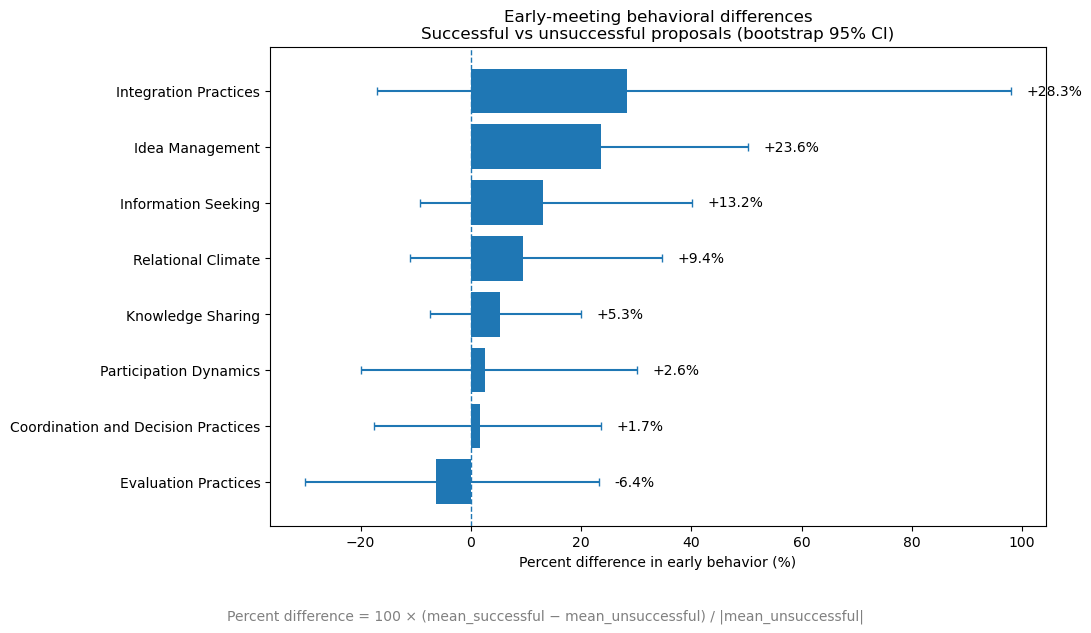

In [10]:
# ============================================================
# SLIDE 6B — Magnitude view (SESSION / PROPOSAL level)
# Early behavioral differences: successful vs unsuccessful proposals
# Percent difference + bootstrap 95% CI
#
# INPUT:
#   df_labeled can be either:
#     - session-level: one row per session_id
#     - individual-level: multiple speakers per session_id
#   -> this cell will collapse to session means if needed.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DF_NAME = "df_labeled"
OUTCOME_COL_CANDIDATES = ["funded_status", "funded_any"]

ANNOTATION_CODES = [
    "Coordination and Decision Practices",
    "Evaluation Practices",
    "Idea Management",
    "Information Seeking",
    "Integration Practices",
    "Knowledge Sharing",
    "Participation Dynamics",
    "Relational Climate",
]

N_BOOT = 2000
RNG_SEED = 0
EPS = 1e-9

# -------------------------
# 1) Load df + pick outcome col
# -------------------------
if DF_NAME not in globals():
    raise NameError(f"{DF_NAME} not found in workspace.")

df_raw = globals()[DF_NAME].copy()

outcome_col = next((c for c in OUTCOME_COL_CANDIDATES if c in df_raw.columns), None)
if outcome_col is None:
    raise ValueError(f"No funded outcome found in {OUTCOME_COL_CANDIDATES}. Columns: {list(df_raw.columns)}")

missing = [c for c in ["session_id", outcome_col] + ANNOTATION_CODES if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# -------------------------
# 2) Enforce SESSION-level (collapse if needed)
# -------------------------
# If df_raw has multiple rows per session_id, average behaviors within session.
# Funding outcome is session-level, so it should be identical within session; we take max to be safe.
df = (
    df_raw
    .groupby("session_id", as_index=False)
    .agg({**{c: "mean" for c in ANNOTATION_CODES}, outcome_col: "max"})
)

y = df[outcome_col].astype(int).values
X = df[ANNOTATION_CODES].apply(pd.to_numeric, errors="coerce").fillna(0.0)

print("=== Slide 6B dataset check (SESSION-level) ===")
print("Rows (sessions):", df.shape[0])
print("Outcome counts (0=unsuccessful, 1=successful):\n", pd.Series(y).value_counts().sort_index())
print("Success rate:", float(y.mean()))

X0 = X[y == 0]
X1 = X[y == 1]
if len(X0) < 5 or len(X1) < 5:
    raise ValueError("Not enough sessions per group for stable estimation.")

# -------------------------
# 3) Percent-difference effect
# -------------------------
mean0 = X0.mean(axis=0)
mean1 = X1.mean(axis=0)
effect = 100.0 * (mean1 - mean0) / (mean0.abs() + EPS)

# -------------------------
# 4) Bootstrap 95% CI (resample sessions)
# -------------------------
rng = np.random.default_rng(RNG_SEED)
boot = np.zeros((N_BOOT, len(ANNOTATION_CODES)), dtype=float)

X0_mat = X0.values
X1_mat = X1.values

for b in range(N_BOOT):
    s0 = rng.choice(len(X0_mat), size=len(X0_mat), replace=True)
    s1 = rng.choice(len(X1_mat), size=len(X1_mat), replace=True)

    m0 = X0_mat[s0].mean(axis=0)
    m1 = X1_mat[s1].mean(axis=0)
    boot[b, :] = 100.0 * (m1 - m0) / (np.abs(m0) + EPS)

ci_low = np.quantile(boot, 0.025, axis=0)
ci_high = np.quantile(boot, 0.975, axis=0)

plot_df = (
    pd.DataFrame({
        "feature": ANNOTATION_CODES,
        "effect_pct": effect.values,
        "CI_low": ci_low,
        "CI_high": ci_high,
    })
    .sort_values("effect_pct")
    .reset_index(drop=True)
)

plot_df["sig_95"] = (plot_df["CI_low"] > 0) | (plot_df["CI_high"] < 0)

print("\n=== Slide 6B table (for notes) ===")
display(plot_df)

# -------------------------
# 5) Plot
# -------------------------
ypos = np.arange(len(plot_df))
fig_h = max(3.5, 0.55 * len(plot_df) + 1.5)
fig, ax = plt.subplots(figsize=(11, fig_h))

ax.barh(ypos, plot_df["effect_pct"].values)
ax.errorbar(
    plot_df["effect_pct"].values,
    ypos,
    xerr=[
        plot_df["effect_pct"].values - plot_df["CI_low"].values,
        plot_df["CI_high"].values - plot_df["effect_pct"].values
    ],
    fmt="none",
    capsize=3
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["feature"].values)
ax.set_xlabel("Percent difference in early behavior (%)")
ax.set_title("Early-meeting behavioral differences\nSuccessful vs unsuccessful proposals (bootstrap 95% CI)")

# annotate values
x_min, x_max = ax.get_xlim()
offset = 0.02 * (x_max - x_min)
for i, (val, hi) in enumerate(zip(plot_df["effect_pct"], plot_df["CI_high"])):
    x_text = min(hi + offset, x_max - offset)
    ax.text(x_text, i, f"{val:+.1f}%", va="center")

fig.text(
    0.5, -0.06,
    "Percent difference = 100 × (mean_successful − mean_unsuccessful) / |mean_unsuccessful|",
    ha="center", fontsize=10, color="gray"
)

plt.tight_layout()
plt.show()

### Slide 6B - checking statistical significance

In [22]:
# ============================================================
# SLIDE 6B — Bootstrap significance summary (clean)
# Criterion: 95% bootstrap CI excludes 0
# Optional: bootstrap two-sided sign probability ("p_boot")
# INPUTS REQUIRED:
#   - plot_df with columns: feature, effect_pct, CI_low, CI_high
# ============================================================

import numpy as np
import pandas as pd

required_cols = {"feature", "effect_pct", "CI_low", "CI_high"}
missing = required_cols - set(plot_df.columns)
if missing:
    raise ValueError(f"plot_df missing columns: {missing}. Has: {list(plot_df.columns)}")

sig_df = plot_df.copy()

# 1) CI-excludes-0 significance flag (this is the correct inferential check for 6B)
sig_df["sig_95"] = (sig_df["CI_low"] > 0) | (sig_df["CI_high"] < 0)

# 2) Direction label (helpful for speaker notes)
sig_df["direction"] = np.where(sig_df["effect_pct"] >= 0, "higher in successful", "higher in unsuccessful")

# 3) Optional: bootstrap "two-sided sign probability" (NOT parametric, just a sanity metric)
# If you have the raw bootstrap draws matrix `boot` from the 6B cell, this is useful.
# boot shape should be (N_BOOT, num_features) in the same feature order as ANNOTATION_CODES.
if "boot" in globals():
    # Map boot columns -> features (assumes ANNOTATION_CODES order)
    if "ANNOTATION_CODES" not in globals():
        print("Note: 'boot' found but 'ANNOTATION_CODES' not found; skipping p_boot.")
    else:
        boot_df = pd.DataFrame(boot, columns=ANNOTATION_CODES)
        # two-sided sign probability: 2 * min(P(boot<=0), P(boot>=0))
        p_boot = []
        for feat in sig_df["feature"]:
            if feat in boot_df.columns:
                p0 = (boot_df[feat] <= 0).mean()
                p1 = (boot_df[feat] >= 0).mean()
                p_boot.append(2 * min(p0, p1))
            else:
                p_boot.append(np.nan)
        sig_df["p_boot"] = p_boot

# 4) Nice display table
sig_df_out = sig_df[["feature", "effect_pct", "CI_low", "CI_high", "sig_95", "direction"] + (["p_boot"] if "p_boot" in sig_df.columns else [])]
sig_df_out = sig_df_out.sort_values("effect_pct", ascending=False).reset_index(drop=True)

print("\n=== Slide 6B: Bootstrap significance summary (95% CI excludes 0) ===")
display(sig_df_out)

print("\nSignificant at 95% bootstrap CI (excludes 0):")
display(sig_df_out[sig_df_out["sig_95"] == True][["feature", "effect_pct", "CI_low", "CI_high", "direction"]])


=== Slide 6B: Bootstrap significance summary (95% CI excludes 0) ===


,feature,effect_pct,CI_low,CI_high,sig_95,direction,p_boot
0,Integration Practices,28.307789,-17.084880,97.889575,False,higher in successful,0.276
1,Idea Management,23.621187,0.989526,50.183575,True,higher in successful,0.041
2,Information Seeking,13.165232,-9.171214,40.071588,False,higher in successful,0.244
3,Relational Climate,9.397099,-11.058386,34.604936,False,higher in successful,0.382
4,Knowledge Sharing,5.332529,-7.475945,19.978698,False,higher in successful,0.418
5,Participation Dynamics,2.642732,-19.949348,30.048288,False,higher in successful,0.838
6,Coordination and Decision Practices,1.667787,-17.650449,23.625078,False,higher in successful,0.848
7,Evaluation Practices,-6.386052,-30.045502,23.215865,False,higher in unsuccessful,0.686



Significant at 95% bootstrap CI (excludes 0):


,feature,effect_pct,CI_low,CI_high,direction
1,Idea Management,23.621187,0.989526,50.183575,higher in successful


In [12]:
# ============================================================
# CHECK: Which early behaviors differ the most?
# Descriptive magnitude comparison (SESSION-level)
# Uses summed early behavioral time
# ============================================================

import pandas as pd
import numpy as np

ANNOTATION_CODES = [
    "Coordination and Decision Practices",
    "Evaluation Practices",
    "Idea Management",
    "Information Seeking",
    "Integration Practices",
    "Knowledge Sharing",
    "Participation Dynamics",
    "Relational Climate",
]

OUTCOME_COL = "funded_any"  # or funded_status

# Start from df_labeled (may be individual-level)
df = df_labeled.copy()

# Collapse to SESSION level (funding is session-level)
df_session = (
    df
    .groupby("session_id", as_index=False)
    .agg({**{c: "mean" for c in ANNOTATION_CODES}, OUTCOME_COL: "max"})
)

# Split groups
X_unsuccessful = df_session[df_session[OUTCOME_COL] == 0][ANNOTATION_CODES]
X_successful   = df_session[df_session[OUTCOME_COL] == 1][ANNOTATION_CODES]

# Compute means
mean_unsuccessful = X_unsuccessful.mean()
mean_successful   = X_successful.mean()

# Percent difference (summed early behavior)
percent_diff = 100 * (mean_successful - mean_unsuccessful) / (mean_unsuccessful.abs() + 1e-9)

# Assemble table
check_df = (
    pd.DataFrame({
        "mean_unsuccessful": mean_unsuccessful,
        "mean_successful": mean_successful,
        "percent_diff": percent_diff,
    })
    .sort_values("percent_diff", ascending=False)
)

print("=== Which early behaviors differ the most? (summed time) ===")
display(check_df)

=== Which early behaviors differ the most? (summed time) ===


,mean_unsuccessful,mean_successful,percent_diff
code,,,
Integration Practices,0.086100,0.110472,28.307789
Idea Management,0.729669,0.902025,23.621187
Information Seeking,0.439410,0.497259,13.165232
Relational Climate,0.411709,0.450397,9.397099
Knowledge Sharing,1.401017,1.475727,5.332529
Participation Dynamics,0.218539,0.224314,2.642732
Coordination and Decision Practices,0.326176,0.331616,1.667787
Evaluation Practices,0.324513,0.303790,-6.386052


## 6B - Individual-level summed annotations

In [13]:
# ============================================================
# CHECK: Individual-level summed early behaviors
# Which behaviors differ the most when COUNTING annotations?
# (NO regression, NO standardization)
# ============================================================

import pandas as pd
import numpy as np

ANNOTATION_CODES = [
    "Coordination and Decision Practices",
    "Evaluation Practices",
    "Idea Management",
    "Information Seeking",
    "Integration Practices",
    "Knowledge Sharing",
    "Participation Dynamics",
    "Relational Climate",
]

OUTCOME_COL = "funded_any"

# Start from individual-level df
df = df_labeled.copy()

# Sanity check
assert "speaker" in df.columns, "This is not individual-level data."

# Split individuals by session outcome
X_unsuccessful = df[df[OUTCOME_COL] == 0][ANNOTATION_CODES]
X_successful   = df[df[OUTCOME_COL] == 1][ANNOTATION_CODES]

# Compute mean summed behavior PER PERSON
mean_unsuccessful = X_unsuccessful.mean()
mean_successful   = X_successful.mean()

# Percent difference
percent_diff = 100 * (mean_successful - mean_unsuccessful) / (mean_unsuccessful.abs() + 1e-9)

# Assemble table
indiv_count_df = (
    pd.DataFrame({
        "mean_unsuccessful": mean_unsuccessful,
        "mean_successful": mean_successful,
        "percent_diff": percent_diff,
    })
    .sort_values("percent_diff", ascending=False)
)

print("=== Individual-level: Which early behaviors differ the most (COUNTED) ===")
display(indiv_count_df)

=== Individual-level: Which early behaviors differ the most (COUNTED) ===


,mean_unsuccessful,mean_successful,percent_diff
code,,,
Idea Management,0.706510,0.891249,26.148165
Integration Practices,0.089652,0.107044,19.399459
Information Seeking,0.436641,0.497858,14.019849
Relational Climate,0.419338,0.464851,10.853454
Knowledge Sharing,1.392875,1.463399,5.063151
Coordination and Decision Practices,0.331531,0.336166,1.397945
Participation Dynamics,0.222752,0.222367,-0.172778
Evaluation Practices,0.308715,0.301198,-2.434853
